In [1]:
import numpy as np
import pytfit5.bls_cpu as gbls
import pytfit5.transitPy5 as tpy5

import matplotlib.pyplot as plt  #MatPlotLib for some simple plots 

import importlib.util #To check if certain libraries are available 

In [2]:
from astropy.io import fits
def read_BOI_phot(fits_fname):
    """ Routine for reading in BOI data from FITS files
    """

    phot = tpy5.phot_class()

    # Open up the FITS files and 
    hdu=fits.open(fits_fname)
    
    lc_time=hdu[1].data['TIME']
    flux=hdu[1].data['FLUX']
    ferr=hdu[1].data['FLUX_ERR']
    # int_time=hdu[0].header['EXPOSURE'] + np.zeros(len(lc_time))
    sec2day = 86400.0
    int_time = np.ones(len(lc_time)) * 1765.5/sec2day #Assume Long-cadnce for this BOI
    qflag=hdu[1].data['SAP_QUALITY']

    hdu.close()

    # Sort the data by time-stamps (in case it's not already) 
    si=np.argsort(lc_time)

    # go through the data and get rid of NaNs, Infs and other trash
    # Identify the indices where there are NaNs in array_with_nan
    nan_indices = np.isnan(flux)

    phot.time  = lc_time[si][~nan_indices]
    phot.flux  = flux[si][~nan_indices]
    phot.ferr  = ferr[si][~nan_indices]
    phot.itime = int_time[si][~nan_indices] # Convert from seconds to days 
    phot.qflag = qflag[si][~nan_indices]

    phot.tflag = np.zeros(len(phot.time))  # Flag for in-transit data
    phot.icut  = np.zeros(len(phot.time))  # Flat for data cuts
    phot.flux_f = np.copy(phot.flux)       # Space to store processed data

    # Normalize photometry
    fmean = np.median(phot.flux)
    phot.flux = phot.flux / fmean
    phot.ferr = phot.ferr / fmean
    
    return phot

In [3]:
tpy5_inputs = tpy5.tpy5_inputs_class() # Initialize unified inputs class (replaces gbls_inputs)

tic = 29991541

## UPDATE TO MATCH YOUR DATA LOCATION AND FILENAME
tpy5_inputs.lcdir = "/opt/data2/rowe/Kepler/bonus/"
tpy5_inputs.filename = "hlsp_kbonus-bkg_kepler_kepler_kic-012059223_kepler_v1.1.1_lc-1.fits"

# Read in photometry to photclass
phot = read_BOI_phot(tpy5_inputs.lcdir + tpy5_inputs.filename)
phot.ferr = np.std(phot.flux) * np.ones_like(phot.flux)  # Set constant error bars if none exist, or errors are poorly defined.  


# Data should be normalized around 1 for BLS.  The example is centred around 1.  So we fix that here.
# phot.flux += 1.0  # Ensure flux is around 1
phot.flux_f = phot.flux   # Make a copy of original flux
# phot.time -= 54900.0 + 0.5 

# Remove any offset from time stamps
tpy5_inputs.zerotime = 0.0

# 0 == no plots ; 1 = make a plot ; 2 make a plot and save it ; 3 just save the plot
tpy5_inputs.plots = 1  #default is 1 

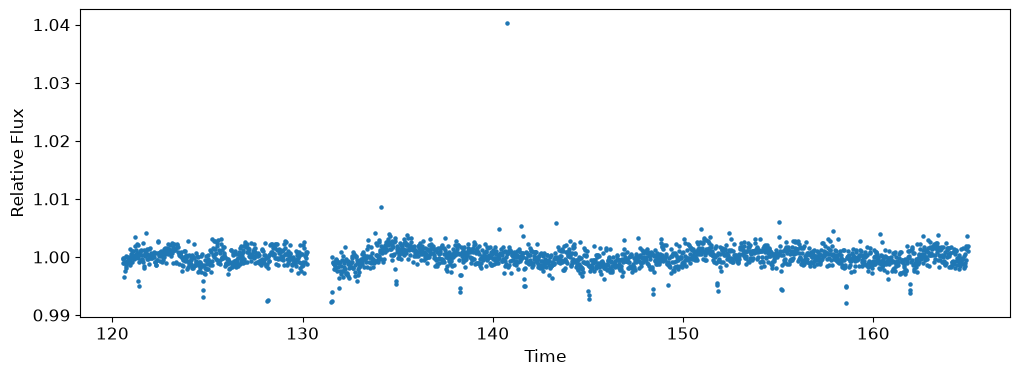

In [4]:
# Raw Light curve 
fig=plt.figure(figsize=(12, 4))
plt.rcParams.update({'font.size': 12})
plt.scatter(phot.time,phot.flux, s=5)
plt.xlabel('Time')
plt.ylabel('Relative Flux')
plt.show()

Starting clipping: Window=2.0 days, Sigma=6
  Iteration 1: flagged 2 new outliers.
  Iteration 2: flagged 0 new outliers.


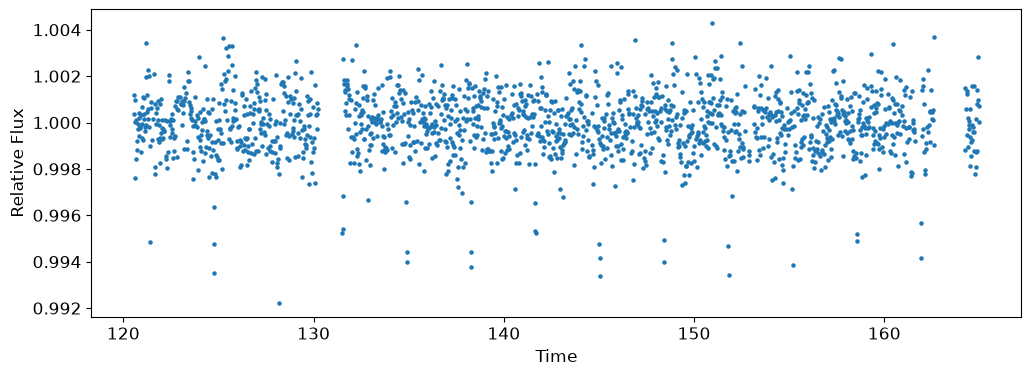

In [5]:
## For testing detrending and outlier removal (can be removed)
phot.flux_f = np.copy(phot.flux)                # Make a copy of original flux
phot.icut = np.zeros(len(phot.time), dtype=int) + phot.qflag # Initialize icut array to zero (good data)

# Get default parameters
tpy5_inputs = tpy5.tpy5_inputs_class()

# Run the detrending and outlier detection (if needed) 
tpy5_inputs.boxbin = 5.0 # set detrending length
tpy5_inputs.nfitp  = 3   # Set polynomial order
tpy5.run_polyfilter_iterative(phot, tpy5_inputs)  # flux_f will contain the filtered photometry
tpy5.run_cutoutliers(phot, tpy5_inputs) # data clipping, phot.icut will flag bad data
# tpy5.run_sigclip_global(phot, tpy5_inputs) # Simple sigma-clipping of data
tpy5_inputs.boxsigma = 6
tpy5.time_window_clip(phot, tpy5_inputs)  # Example of custom time-window clipping function

# Processed Light curve 
fig=plt.figure(figsize=(12, 4))
plt.rcParams.update({'font.size': 12})
plt.scatter(phot.time[(phot.icut==0)],phot.flux_f[(phot.icut==0)], s=5)
# plt.scatter(phot.time[phot.icut==0],phot.flux_f[phot.icut==0], s=5)
plt.xlabel('Time')
plt.ylabel('Relative Flux')
plt.show()

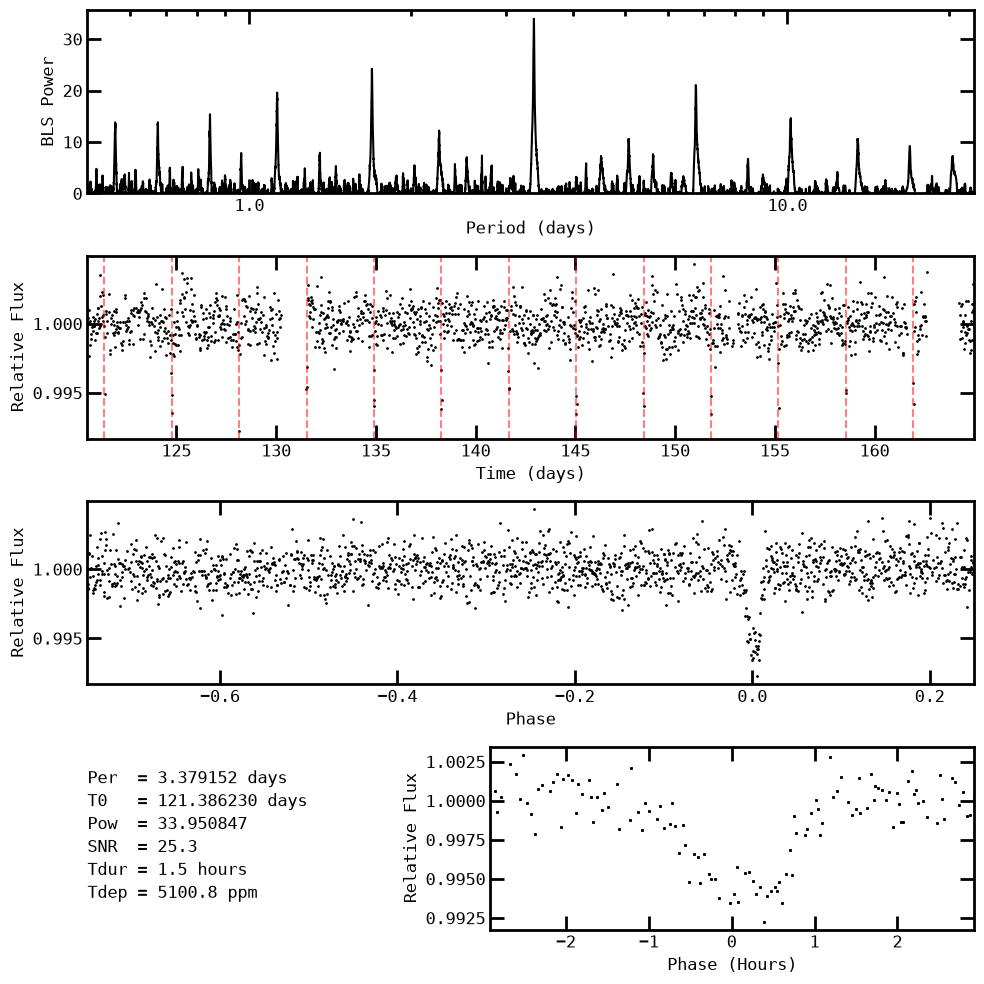

In [6]:
# Set up the BLS inputs and run
# Note: tpy5_inputs now contains both BLS and detrending parameters
tpy5_inputs.zerotime = 0.0
tpy5_inputs.rstar    = 1.0
tpy5_inputs.mstar    = 1.0
tpy5_inputs.plots    = 1 # 1=X11, 2=both, 0=none
# Set frequency range
# For long periods: frequency = 1/period (cycles/day = 1/days)
# To search down to period = baseline, use freq1 = 1/baseline
tpy5_inputs.freq1    = 2 / (np.max(phot.time) - np.min(phot.time))  # Longest period = dataset length
tpy5_inputs.freq2    = -1 # default is 2.0 c/d (period = 0.5 days)
tpy5_inputs.filename = "BLS_Test"  # Used for naming the file, extension replaced with PNG.


tpy5_inputs.normalize = "iterative_baseline"  # "coverage_mad" "mad", "percentile_mad", "none"

# Run BLS, applying data cuts (now using unified tpy5_inputs)
gbls_ans = gbls.bls(tpy5_inputs, phot.time[(phot.icut==0)], \
                                 phot.flux_f[(phot.icut==0)])

## Lightcurve Summary Plot

Use `transitp.plot_lightcurve_summary()` to visualize raw and detrended photometry, optionally with BLS results.

In [7]:
import pytfit5.transitplot as transitp

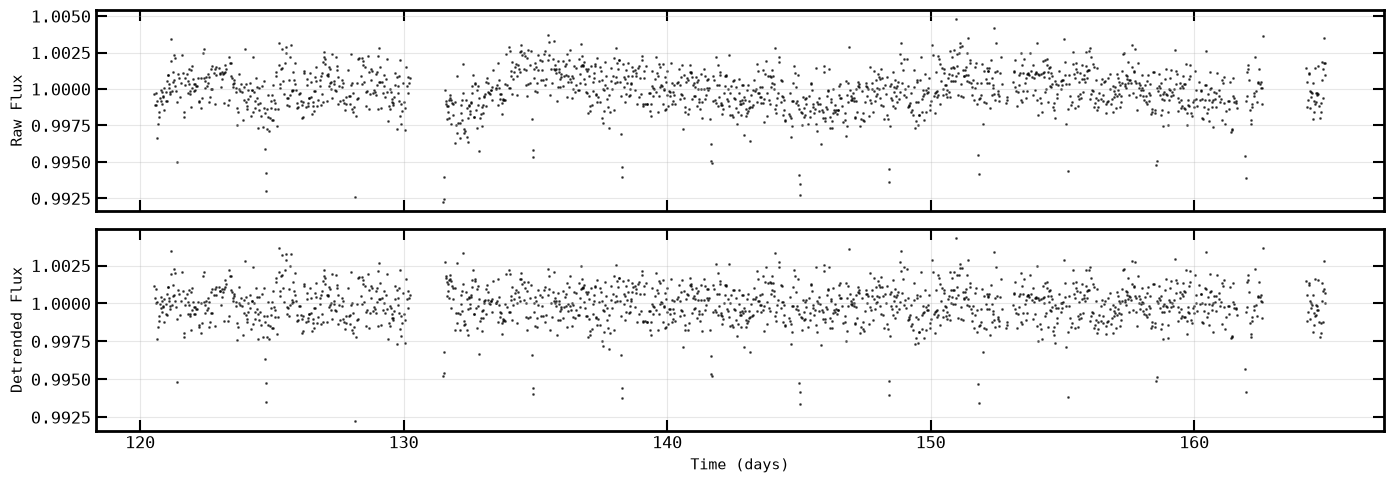

In [8]:
# Plot summary without BLS results (just raw and detrended)
fig = transitp.plot_lightcurve_summary(phot, tpy5_inputs=tpy5_inputs)

/home/rowe/python/Kepler-BOI1b/.boi1/lib64/python3.13/site-packages/pytfit5/transitplot.py:524: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


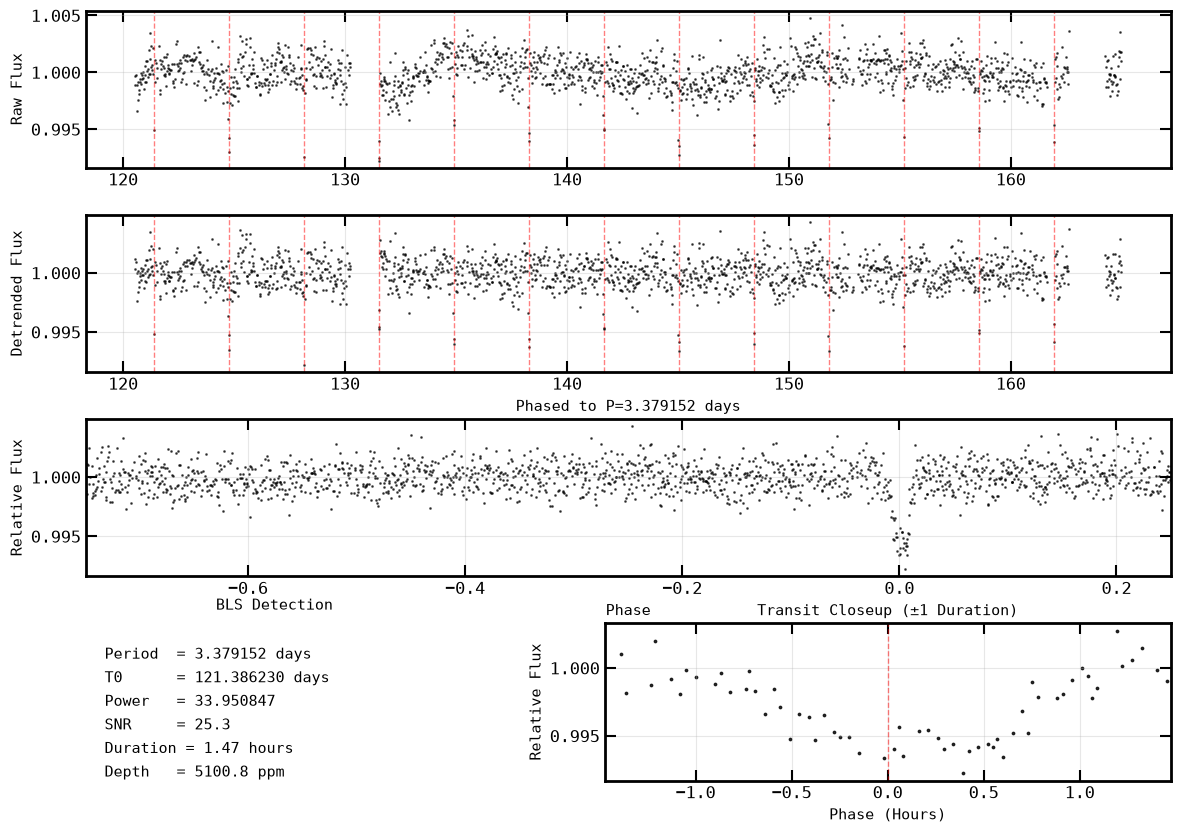

In [9]:
# Plot summary with BLS results (includes phased lightcurve and transit closeup)
fig = transitp.plot_lightcurve_summary(phot, bls_ans=gbls_ans, tpy5_inputs=tpy5_inputs)

## Python Transit modelling section

- needs preconditioning of data prior to modelling. (protect transits during detrending and clipping)
- move zerotime to routine to leave original phot.time intack
- use flux_f instead of flux for modelling -- leaves original photometry intack
- use icut and other flags to mark bad data 

In [10]:
import pytfit5.transitmodel as transitm
import pytfit5.keplerian as kep
import pytfit5.transitfit as transitf
import pytfit5.transitplot as transitp

#Stupid fix for all the packages that use pkg_resources
import sys
try:
    import pkg_resources
except ImportError:
    import pip._vendor.pkg_resources as pkg_resources
    sys.modules['pkg_resources'] = pkg_resources

# Check for optional exotic limb darkening package.
if importlib.util.find_spec("exotic_ld"):
    from exotic_ld import StellarLimbDarkening
    use_exotic_ld = 1
else:
    use_exotic_ld = 0

In [11]:
# Create an initial guess for all 18 parameters
sol     = transitm.transit_model_class() # Single planet model has up-to 18-model parameters

# Parameters that define the star/scene for the transit model
sol.rho = kep.rhostar(gbls_ans.bper, gbls_ans.tdur)    # Guess for mean stellar density based on transit-duration and period (g/cm^3)
sol.nl1 = 0.0    # Only used for non-linear limb-darkening 
sol.nl2 = 0.0    # Only used for non-linear limb-darkening
sol.dil = 0.0    # dilution
sol.vof = 0.0    # Velocity offset
sol.zpt = 0.0    # Photometric zero point

tpy5_inputs.teff = 3834.0  # Effective temperature (K)
tpy5_inputs.logg = 4.76      # Surface gravity (cgs)
tpy5_inputs.feh  = 0.0      # Metallicity ([Fe/H])

# Set up Limb-darkening (q1, q2 parameterization)
if use_exotic_ld == 1:
    import pandas as pd
    ld_data_path = './exotic_ld_data/'  # location of exotic spectral library
    ld_model = 'mps1'
    sld = StellarLimbDarkening(tpy5_inputs.feh, tpy5_inputs.teff, tpy5_inputs.logg, ld_model, ld_data_path)

    # Load Kepler throughput curve (exotic_ld has no built-in Kepler mode; we use 'custom')
    kepler_df = pd.read_csv('/home/rowe/python/bls_cuda/exotic_ld_data/Sensitivity_files/Kepler_throughput.csv')
    kepler_wavelengths  = kepler_df['wave'].values   # Angstroms
    kepler_throughput   = kepler_df['tp'].values

    ld, ld_sig = sld.compute_kipping_ld_coeffs(
        wavelength_range=[kepler_wavelengths.min(), kepler_wavelengths.max()],
        mode='custom',
        custom_wavelengths=kepler_wavelengths,
        custom_throughput=kepler_throughput,
        mu_min=0.1,
        return_sigmas=True
    )
    sol.nl3 = ld[0]
    sol.nl4 = ld[1]
    print(f"Using Kepler limb-darkening coefficients: nl3={sol.nl3:.3f} +/- {ld_sig[0]:.3f}, nl4={sol.nl4:.3f} +/- {ld_sig[1]:.3f}")
else:
    sol.nl3 = 0.311  # Default solar values (TESS-like)
    sol.nl4 = 0.270
    print(f"Using default limb-darkening coefficients: nl3={sol.nl3:.3f}, nl4={sol.nl4:.3f}")

#The parameters below are stored as arrays, as the model is multi-planet ready.
sol.t0  = [gbls_ans.epo]             # Center of transit time (days)
sol.per = [gbls_ans.bper]            # Orbital Period (days)
sol.bb  = [0.5]                      # Impact parameter
sol.rdr = [np.sqrt(gbls_ans.depth)]  # Rp/R*
sol.ecw = [0.0]                      # sqrt(e)cos(w)
sol.esw = [0.0]                      # sqrt(e)sin(w)
sol.krv = [0.0]                      # RV amplitude (m/s)
sol.ted = [0.0]                      # thermal eclipse depth (ppm)
sol.ell = [0.0]                      # Ellipsodial variations (ppm)
sol.alb = [0.0]                      # Albedo amplitude (ppm)
sol.npl = 1                          # Number of planets

Using Kepler limb-darkening coefficients: nl3=0.488 +/- 0.006, nl4=0.294 +/- 0.010


In [12]:
# Mark in-transit data.  Since BLS will likely underestimate the transit-duration, we will pad to be safe.
kep.mark_intransit_data(phot, sol, tdurcut = 1.0)  # tdurcut is the amount of +/- time to protect centred on the transit 
tpy5.run_polyfilter(phot, tpy5_inputs)         # Re-apply detrending to protect the transit event from distortion

In [13]:
f_model = transitm.transitModel(sol, phot.time)

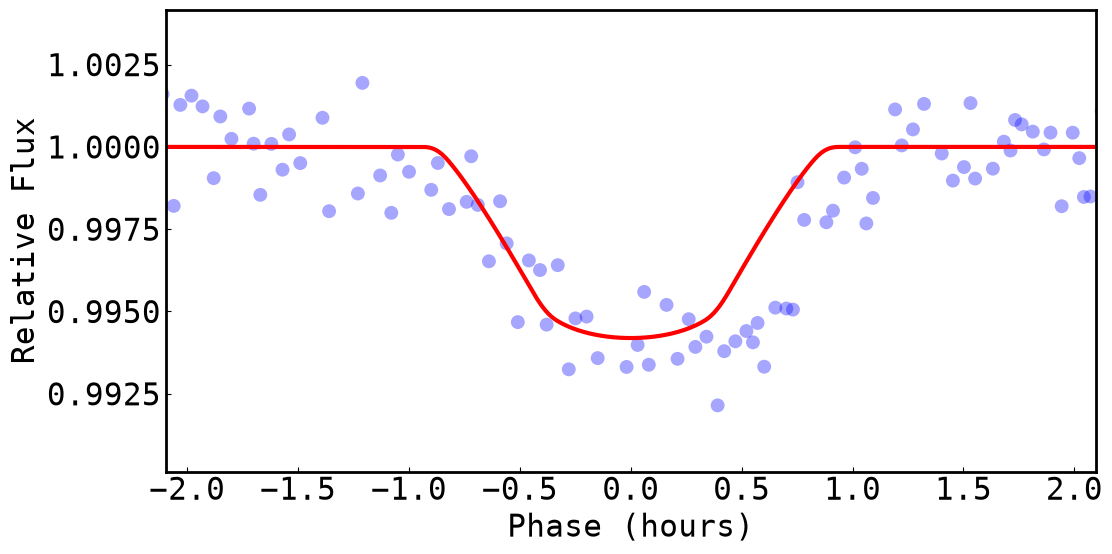

In [14]:
# Plot the initial model and data
pl_plot = 1 # Which planet to plot
transitp.plotTransit(phot, sol, pl_to_plot=pl_plot)

In [15]:
# Define the parameters to fit
params_to_fit = ["rho", "zpt", "t0", "per", "bb", "rdr"]

# Update to use +/- 1.0 tdur
kep.mark_intransit_data(phot, sol, tdurcut = 2.0)

# Fit the data
sol_fit = transitf.fitTransitModel(sol, params_to_fit, phot)

In [16]:
# See the fitted parameter (Note the error is a simple co-variance matrix at this stage)
transitp.printParams(sol_fit)

ρ* (g/cm³):                     1.1035118 ± 1.3406325
c1:                                   0.0 ± 0.0
c2:                                   0.0 ± 0.0
q1:                             0.4884049 ± 0.0000000
q2:                             0.2935053 ± 0.0000000
Dilution:                             0.0 ± 0.0
Velocity Offset:                      0.0 ± 0.0
Photometric zero point:         3.196e-05 ± 2.132e-04
Error scale factor:                   1.0 ± 0.0
t0 (days):                     121.3907030 ± 0.0029666
Period (days):                  3.3792311 ± 0.0004272
Impact parameter:               0.8598458 ± 0.1329212
Rp/R*:                          0.0840853 ± 0.0124832
sqrt(e)cos(w):                        0.0 ± 0.0
sqrt(e)sin(w):                        0.0 ± 0.0
RV Amplitude (m/s):                   0.0 ± 0.0
Thermal eclipse depth (ppm):          0.0 ± 0.0
Ellipsoidal variations (ppm):         0.0 ± 0.0
Albedo amplitude (ppm):               0.0 ± 0.0


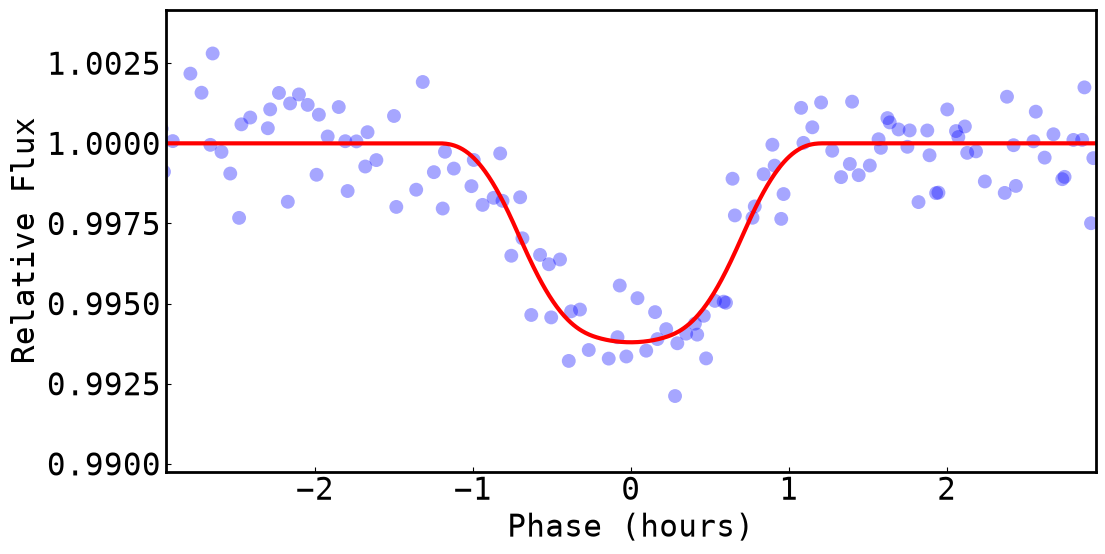

In [17]:
# Plot the optimized model and data
pl_plot = 1
transitp.plotTransit(phot, sol_fit, pl_to_plot=pl_plot)

## MCMC

- add tqdm to MCMC chain generation to give user an indication of progress
- add flag to remove verbose output
- add figure generation that plots a selection of models from MCMC to show scatter. 

In [18]:
import pytfit5.transitmcmc as tmcmc

In [19]:
nsteps1 = 10000 #total length of chain will be nwalkers*nsteps
nsteps2 = 50000#200000 #nstep1 is to check that MCMC is okay, nstep2 is the real work.
nsteps_inc = 50000#100000
burninf=0.2 #burn-in for evalulating convergence
niter_cor=10000
burnin_cor=1000
nthin=101
nloopmax=5
converge_crit=1.02 #Convergence criteria
buf_converge_crit=1.2 #Convergence criteria for buffer

In [20]:
if np.rint(np.median(phot.flux)) != 1:
    raise ValueError


# Update fitted parameters to include dscale for error scaling.
params_to_fit = ["rho", "nl3", "nl4", "zpt", "t0", "per", "bb", "rdr", "dscale"]

# Set Gaussian soft priors for limb-darkening coefficients.
# Format: [mean, sigma_up, sigma_lo]  (split-normal; equal sigmas = symmetric Gaussian)
# Values from exotic_ld / theoretical tables for this star.
priors = tmcmc.priors_class()
priors.nl3 = [0.488, 0.006, 0.006]   # q1 limb-darkening prior
priors.nl4 = [0.294, 0.010, 0.010]   # q2 limb-darkening prior

# Generate input for mcmc
lnprob, x, beta = tmcmc.genmcmcInput(sol_fit, params_to_fit, priors=priors)  # Beta can be crap when pulled from least-squares...

# defaults when fitting for limb-darkening
beta[1] = 0.01 
beta[2] = 0.01

# # beta is the step size for each parameter in x and initialized from the covariance matrix.
# # Here we set some reasonable values for our parameters to fit. 
# beta[0] = 0.01 # Set a reasonable step size for stellar density
# beta[1] = 0.00001 # Set a reasonable step size for photometric zero point
# beta[2] = 0.00001 # Set a reasonable step size for transit time
# beta[3] = 0.00001 # Set a reasonable step size for period
# beta[4] = 0.1  # Set a reasonable step size for impact parameter
# beta[5] = 0.0001 # Set a reasonable step size for radius ratio

sol_a = sol_fit.to_array()
serr = sol_fit.err_to_array()

# Cut out of transit
phot_cut = tmcmc.cutOutOfTransit(sol_fit, phot, tdurcut=2.0)

params = [nsteps1, nsteps2, nsteps_inc, burninf, niter_cor, burnin_cor, nthin, nloopmax, converge_crit, buf_converge_crit]

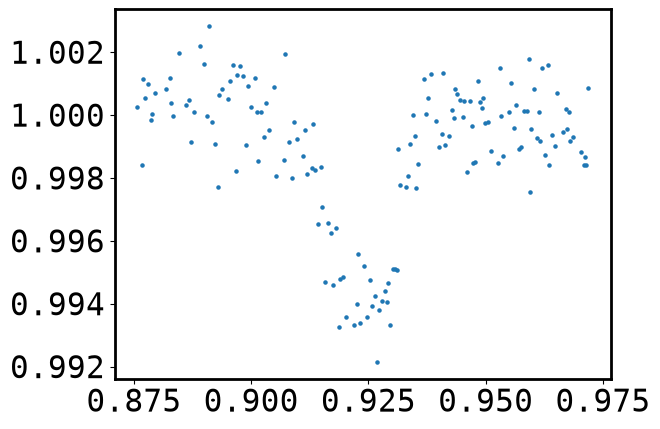

In [21]:
phot_cut.tflag = np.ones(len(phot_cut.time), dtype=int) # Initialize tflag array to one (out-of-transit data)
selection_mask = (phot_cut.icut == 0) & (phot_cut.tflag == 1)
plt.scatter((phot_cut.time[selection_mask]/sol.per)-np.floor(phot_cut.time[selection_mask]/sol.per), phot_cut.flux_f[selection_mask], s=5)

In [22]:
# Run the DEMCMC routine.
chain, accept, burnin = tmcmc.demcmcRoutine(x, beta, phot_cut, sol_a, serr, params, lnprob)

runtest: [1.22530430e-02 6.83234193e-03 1.46252394e-04 4.31008711e-05]
Current Acceptance:  [0.10893032 0.57645875 0.70977597 0.43004115 0.37462236 0.35880077
 0.13347023 0.14464802 0.95721393]
Current Acceptance:  [0.15549077 0.35234216 0.39656816 0.30439122 0.27235772 0.26960784
 0.57171118 0.18941799 0.72469636]
Current Acceptance:  [0.25468904 0.2016129  0.18913676 0.18315377 0.27235772 0.26960784
 0.73253493 0.22233607 0.16482412]
Current Acceptance:  [0.25468904 0.14482759 0.1278826  0.15877712 0.27235772 0.26960784
 0.30371901 0.22233607 0.06647673]
Current Acceptance:  [0.25468904 0.17802645 0.13941825 0.21865889 0.27235772 0.26960784
 0.35076923 0.22233607 0.08579882]
Current Acceptance:  [0.25468904 0.21607516 0.22386588 0.26522593 0.27235772 0.26960784
 0.16129032 0.22233607 0.1817279 ]
Current Acceptance:  [0.25468904 0.25389105 0.22386588 0.26522593 0.27235772 0.26960784
 0.04402516 0.22233607 0.27517448]
Current Acceptance:  [0.25468904 0.25389105 0.22386588 0.26522593 0.

In [23]:
# Get statistics about the posterior from the Markov-Chain and print the results
sol_mcmc = tmcmc.getParams(chain, burnin, sol, params_to_fit)
transitp.printParams(sol_mcmc)

# you can get any individual value from the sol_mcmc class, for example the mean stellar density : rho and drho 

ρ* (g/cm³):                     4.7504141 ± 3.6504000
c1:                                   0.0 ± 0.0
c2:                                   0.0 ± 0.0
q1:                             0.4879366 ± 0.0060283
q2:                             0.2940774 ± 0.0099927
Dilution:                             0.0 ± 0.0
Velocity Offset:                      0.0 ± 0.0
Photometric zero point:        -4.004e-05 ± 9.864e-05
Error scale factor:             0.5990889 ± 0.0338663
t0 (days):                     121.3908807 ± 0.0018650
Period (days):                  3.3792022 ± 0.0002596
Impact parameter:               0.5363027 ± 0.2772260
Rp/R*:                          0.0731584 ± 0.0056816
sqrt(e)cos(w):                        0.0 ± 0.0
sqrt(e)sin(w):                        0.0 ± 0.0
RV Amplitude (m/s):                   0.0 ± 0.0
Thermal eclipse depth (ppm):          0.0 ± 0.0
Ellipsoidal variations (ppm):         0.0 ± 0.0
Albedo amplitude (ppm):               0.0 ± 0.0


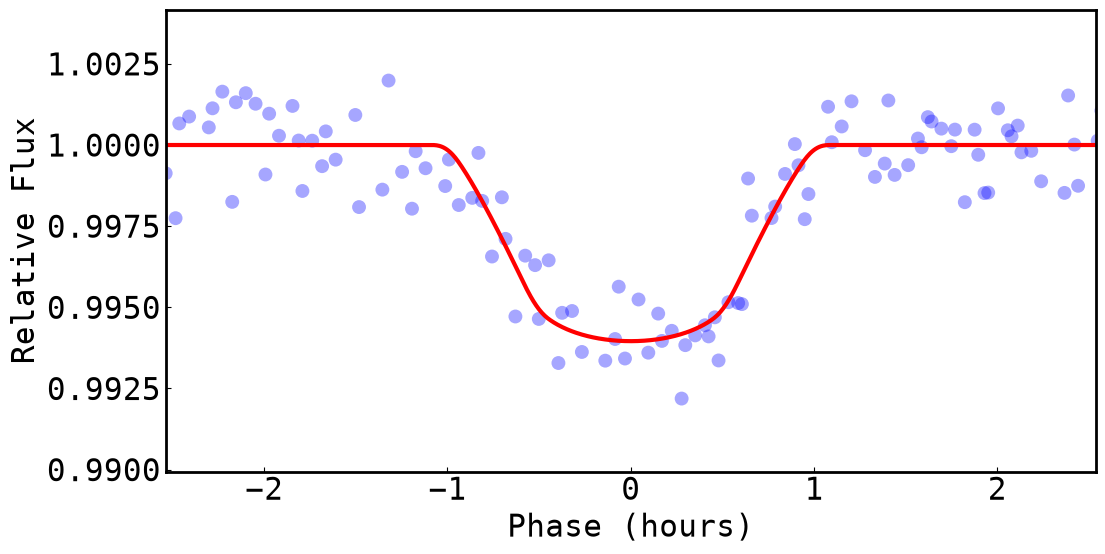

In [24]:
pl_plot = 1
# phot.itime = 0.00001*np.ones_like(phot.time) # Set a small itime to avoid issues with plotting when itime=0
transitp.plotTransit(phot, sol_mcmc, pl_to_plot=pl_plot)

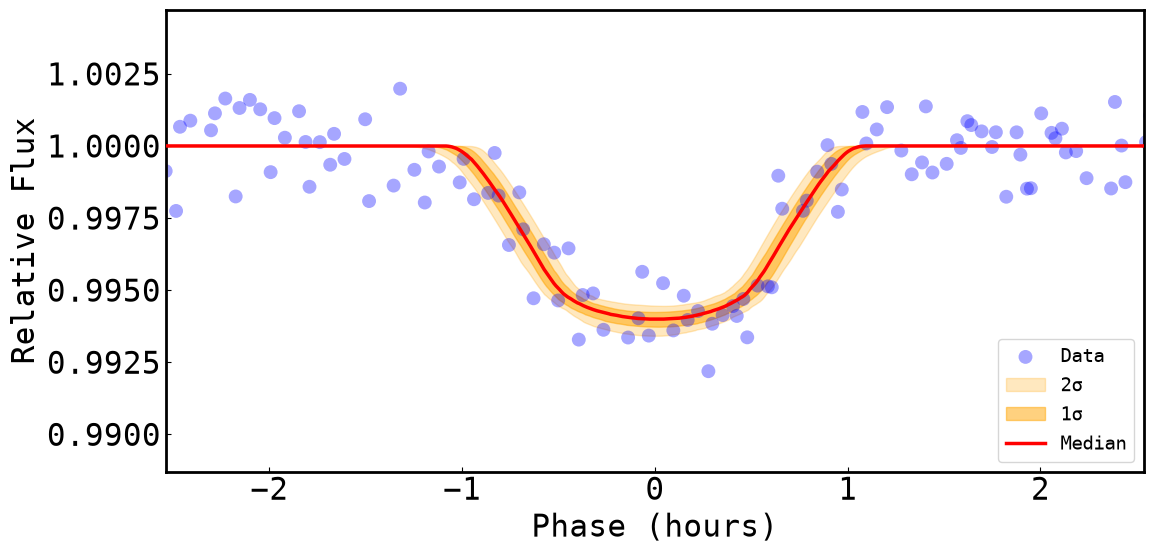

In [25]:
# Plot MCMC posterior confidence intervals on the phase-folded transit
# Draws n_samples rows from the post-burnin chain to build 1-sigma and 2-sigma envelopes.
pl_plot = 1
fig = transitp.plotTransitMCMC(chain, burnin, sol, params_to_fit, phot,
                                pl_to_plot=pl_plot, n_samples=300)

In [26]:
import pytfit5.mcmcroutines as mcmc

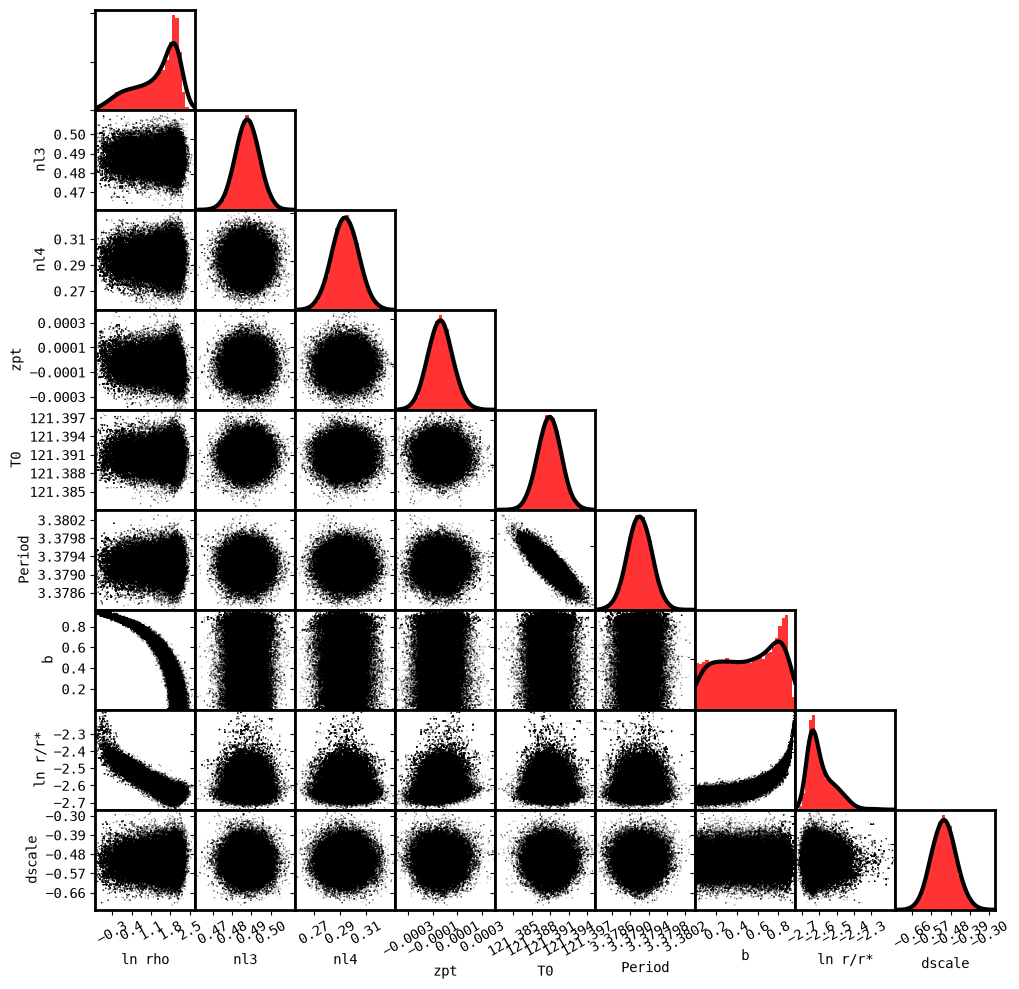

In [27]:
label = ["ln rho", "nl3", "nl4", "zpt", "T0", "Period", "b", "ln r/r*", "dscale"]
color = ["red"]*len(label)

plt.rcParams['font.size'] = 10
mcmc.triplot(chain, burnin, label, color, 30)